Image shape: (6000, 3375, 3)


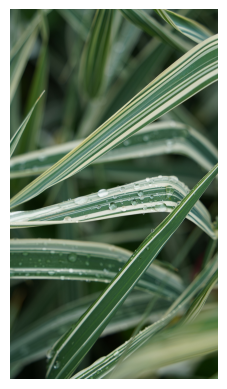

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import time

from numba import cuda

def load_and_display_image(file_path):
        img = mpimg.imread(file_path)

        print(f"Image shape: {img.shape}")

        plt.imshow(img)
        plt.axis('off')
        plt.show()

        return img

image_path = "image.jpg"
img = load_and_display_image(image_path)

h = img.shape[0]
w = img.shape[1]

pixelCount = h*w
blockSize = 64
gridSize = int(pixelCount/blockSize)



In [3]:
gaussian_filter = np.array([
    [0, 0, 1, 2, 1, 0, 0],
    [0, 3, 13, 22, 13, 3, 0],
    [1, 13, 59, 97, 59, 13, 1],
    [2, 22, 97, 159, 97, 22, 2],
    [1, 13, 59, 97, 59, 13, 1],
    [0, 3, 13, 22, 13, 3, 0],
    [0, 0, 1, 2, 1, 0, 0]
], dtype=np.float32)

gaussian_filter /= np.sum(gaussian_filter)

CPU time: 2400.6110842227936 seconds


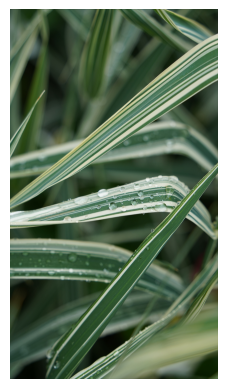

In [3]:
def gaussian_blur_cpu(src, gaussian_filter):
    dst = np.zeros((h, w, 3), dtype=np.uint8)

    for y in range(h):
        for x in range(w):

            for c in range(3):
                value = 0.0

                for ky in range(7):
                    for kx in range(7):

                        ix = x + kx - 3
                        iy = y + ky - 3

                        if (
                            ix >= 0 and ix < w and
                            iy >= 0 and iy < h
                        ):
                            value += (
                                src[iy, ix, c]
                                * gaussian_filter[ky, kx]
                            )

                dst[y, x, c] = np.uint8(value)

    return dst


start_cpu = time.time()

blur = gaussian_blur_cpu(img,gaussian_filter)

end_cpu = time.time()

cpu_time = end_cpu - start_cpu

print("CPU time:", cpu_time, "seconds")


gray_image_cpu = blur.reshape((h, w, 3))

plt.imshow(gray_image_cpu)
plt.axis('off')
plt.show()

GPU without shared memory:  0.0004398822784423828


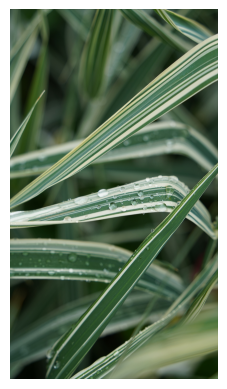

In [30]:
import math

blockSize = (16, 16)

gridSize = (
    math.ceil(w / blockSize[0]),
    math.ceil(h / blockSize[1])
)

@cuda.jit
def gaussian_blur(src, dst, filter):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

    if x < src.shape[1] and y < src.shape[0]:

        for c in range(3):
            value = 0.0

            for ky in range(7):
                for kx in range(7):

                    ix = x + kx - 3
                    iy = y + ky - 3

                    if ix >= 0 and ix < src.shape[1] and iy >= 0 and iy < src.shape[0]:

                        value += src[iy, ix, c] * filter[ky, kx]

            dst[y, x, c] = np.uint8(value)


devSrc = cuda.to_device(img)
filter = cuda.to_device(gaussian_filter)
devDst = cuda.device_array((h, w, 3), np.uint8)

gaussian_blur[gridSize, blockSize](devSrc,devDst,filter)
cuda.synchronize()
start = time.time()
gaussian_blur[gridSize, blockSize](devSrc,devDst,filter)
end = time.time()
measure_time = end - start
print("GPU without shared memory: ", measure_time)

hostDst = devDst.copy_to_host()

plt.imshow(hostDst)
plt.axis('off')
plt.show()

In [31]:
block_sizes = [
    (8,8),
    (16,16),
    (32,16),
    (16,32),
    (32,32)
]
gpu_times = []

for blockSize in block_sizes:

    gridSize = (
        math.ceil(w / blockSize[0]),
        math.ceil(h / blockSize[1])
    )

    devSrc = cuda.to_device(img)
    devDst = cuda.device_array((h, w, 3), np.uint8)

    gaussian_blur[gridSize, blockSize](devSrc,devDst,filter)
    hostDst = devDst.copy_to_host()

    cuda.synchronize()

    times = []

    for i in range(5):

        start = time.time()

        gaussian_blur[gridSize, blockSize](devSrc,devDst,filter)

        end = time.time()

        times.append(end - start)
        hostDst = devDst.copy_to_host()

    average_time = sum(times) / 5

    gpu_times.append(average_time)
    # plt.imshow(hostDst)
    # plt.axis('off')
    # plt.show()

    print("Block size:", blockSize)
    print("Times:", times)
    print("Average:", average_time)

Block size: (8, 8)
Times: [0.0002281665802001953, 0.0003066062927246094, 0.00021004676818847656, 0.0001952648162841797, 0.00018167495727539062]
Average: 0.0002243518829345703
Block size: (16, 16)
Times: [0.0001232624053955078, 0.00013685226440429688, 0.00018072128295898438, 0.00018930435180664062, 0.00019311904907226562]
Average: 0.00016465187072753907
Block size: (32, 16)
Times: [0.00022459030151367188, 0.0001823902130126953, 0.0002067089080810547, 0.00019812583923339844, 0.00020360946655273438]
Average: 0.00020308494567871093
Block size: (16, 32)
Times: [0.00012636184692382812, 0.00017213821411132812, 0.0001919269561767578, 0.00016641616821289062, 0.0001780986785888672]
Average: 0.00016698837280273437
Block size: (32, 32)
Times: [0.00015211105346679688, 0.00018644332885742188, 0.00020885467529296875, 0.00015854835510253906, 0.00013709068298339844]
Average: 0.000168609619140625


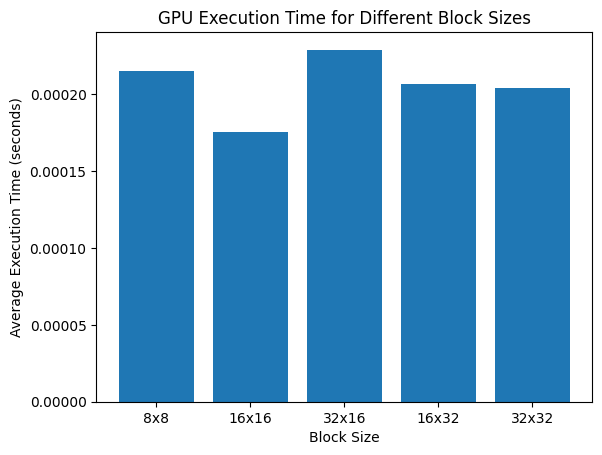

In [6]:
labels = [f"{x}x{y}" for x, y in block_sizes]

plt.bar(labels, gpu_times)

plt.xlabel("Block Size")
plt.ylabel("Average Execution Time (seconds)")
plt.title("GPU Execution Time for Different Block Sizes")

plt.show()

In [42]:
from numba import cuda, float32

@cuda.jit
def gaussian_blur_shared(src, dst, gaussian_filter):

    shared_filter = cuda.shared.array((7, 7), dtype=float32)

    tx = cuda.threadIdx.x
    ty = cuda.threadIdx.y

    x = tx + cuda.blockIdx.x * cuda.blockDim.x
    y = ty + cuda.blockIdx.y * cuda.blockDim.y

    thread_id = ty * cuda.blockDim.x + tx

    if thread_id < 49:

        ky = thread_id // 7
        kx = thread_id % 7

        shared_filter[ky, kx] = gaussian_filter[ky, kx]

    cuda.syncthreads()

    if x < src.shape[1] and y < src.shape[0]:

        for c in range(3):

            value = 0.0

            for ky in range(7):
                for kx in range(7):

                    ix = x + kx - 3
                    iy = y + ky - 3

                    if (
                        ix >= 0 and ix < src.shape[1] and
                        iy >= 0 and iy < src.shape[0]
                    ):

                        value += (
                            src[iy, ix, c] *
                            shared_filter[ky, kx]
                        )

            dst[y, x, c] = np.uint8(value)

GPU with shared memory: 0.12280893325805664


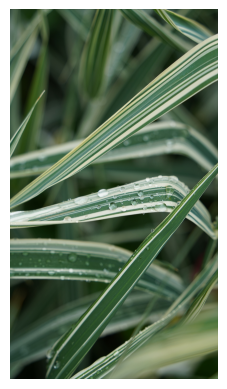

In [43]:
devSrc = cuda.to_device(img)
devFilter = cuda.to_device(gaussian_filter)

devDst = cuda.device_array((h, w, 3), dtype=np.uint8)

gaussian_blur_shared[gridSize, blockSize](devSrc, devDst, devFilter)

cuda.synchronize()

start = time.time()

gaussian_blur_shared[gridSize, blockSize](devSrc, devDst, devFilter)

cuda.synchronize()

end = time.time()

measure_time = end - start

print("GPU with shared memory:", measure_time)


hostDst = devDst.copy_to_host()

plt.imshow(hostDst)
plt.axis("off")
plt.show()

In [44]:
block_sizes = [
    (8, 8),
    (16, 16),
    (32, 16),
    (16, 32),
    (32, 32)
]

gpu_times_share = []

devSrc = cuda.to_device(img)
devFilter = cuda.to_device(gaussian_filter)

for blockSize in block_sizes:

    gridSize = (
        math.ceil(w / blockSize[0]),
        math.ceil(h / blockSize[1])
    )

    devDst = cuda.device_array((h, w, 3),dtype=np.uint8)

    # Warm-up
    gaussian_blur_shared[gridSize, blockSize](devSrc, devDst, devFilter)

    cuda.synchronize()

    times = []

    for i in range(5):

        start = time.time()

        gaussian_blur_shared[gridSize, blockSize](devSrc, devDst, devFilter)

        cuda.synchronize()

        end = time.time()

        times.append(end - start)

    average_time = sum(times) / len(times)

    gpu_times_share.append(average_time)

    print("Block size:", blockSize)
    print("Times:", times)
    print("Average:", average_time)
    print()

Block size: (8, 8)
Times: [0.0802912712097168, 0.07927179336547852, 0.06862711906433105, 0.05818605422973633, 0.05958366394042969]
Average: 0.06919198036193848

Block size: (16, 16)
Times: [0.05827760696411133, 0.0582118034362793, 0.058046579360961914, 0.05879402160644531, 0.05851626396179199]
Average: 0.05836925506591797

Block size: (32, 16)
Times: [0.05783963203430176, 0.05788111686706543, 0.05851149559020996, 0.058882713317871094, 0.05803871154785156]
Average: 0.05823073387145996

Block size: (16, 32)
Times: [0.05892515182495117, 0.05889272689819336, 0.05853915214538574, 0.05862689018249512, 0.05887031555175781]
Average: 0.05877084732055664

Block size: (32, 32)
Times: [0.0590665340423584, 0.05877041816711426, 0.0596613883972168, 0.05914497375488281, 0.05897378921508789]
Average: 0.05912342071533203



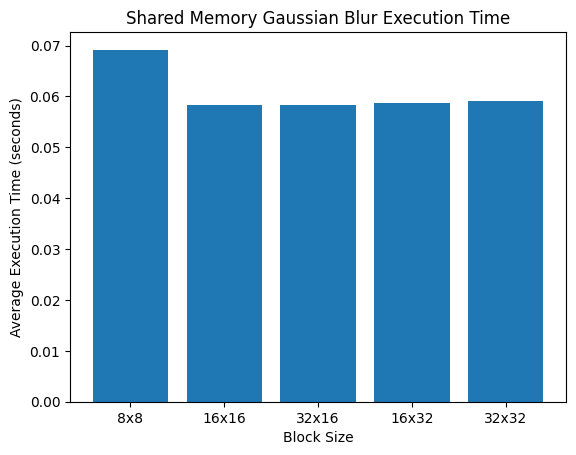

In [45]:
labels = [f"{x}x{y}" for x, y in block_sizes]

plt.bar(labels, gpu_times_share)

plt.xlabel("Block Size")
plt.ylabel("Average Execution Time (seconds)")
plt.title("Shared Memory Gaussian Blur Execution Time")

plt.show()

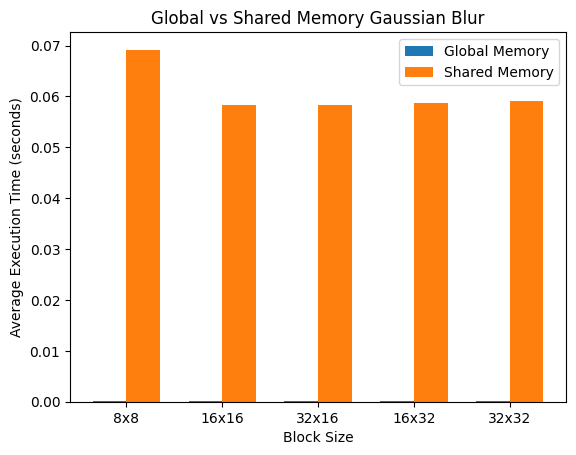

In [46]:
labels = [f"{x}x{y}" for x, y in block_sizes]

x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, gpu_times, width, label="Global Memory")
plt.bar(x + width/2, gpu_times_share, width, label="Shared Memory")

plt.xlabel("Block Size")
plt.ylabel("Average Execution Time (seconds)")
plt.title("Global vs Shared Memory Gaussian Blur")

plt.xticks(x, labels)
plt.legend()

plt.show()